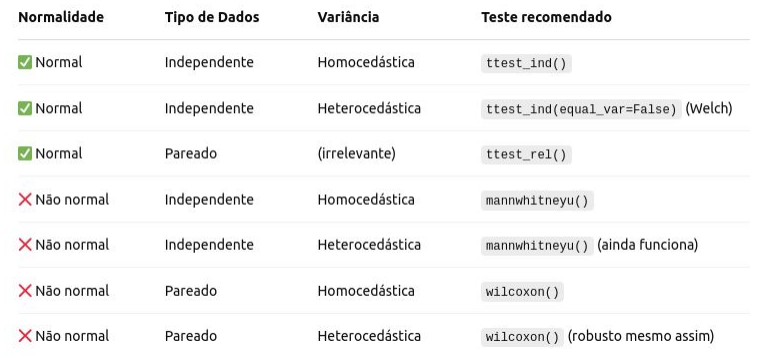

**Hipóteses pensadas:**

**1. O nível de Birita Dog tem relação com a quantidade de pessoas que deram PT no churrasco?**

    H0 = O nível de birita é igual para quem deu PT e quem não deu PT

    H1 = Quem deu PT possui nível de birita maior

---

**2. A chegada do carvão tem influência sobre a temperatura do churrasqueiro?**


    H0 = Chegar cedo (antes das 13h) com o carvão não altera a temperatura do churrasqueiro

    H1 = Chegar cedo (antes das 13h) com o carvão produz temperaturas maiores

---

**3. Quem cantou evidências bebeu mais?**

    H0 = Quem possui alto nível de birita canta Evidências tanto quanto os demais

    H1 = Quem possui alto nível de birita canta Evidências mais vezes

In [ ]:
import pandas as pd
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind

df = pd.read_csv("dataset_pt_churrasco.csv")
df.columns

Index(['quantidade_picanha', 'tempo_médio_de_boteco',
       'n_de_amigos_com_nome_junior', 'índice_de_solvência_do_cooler',
       'quantas_tias_fizeram_maionese', 'cor_do_terno_que_vai_sujar',
       'vezes_que_cantou_evidências', 'nível_de_birita_dog',
       'horario_chegada_carvao', 'temperatura_churrasqueiro',
       'pt_no_churrasco'],
      dtype='object')

In [ ]:
## set de dados p hipoteses
## 1° hipotese: O nível de Birita Dog tem relação com a quantidade de pessoas que deram PT no churrasco?

grupo_pt = df[df["pt_no_churrasco"] == 1]["nível_de_birita_dog"]
grupo_nao_pt = df[df["pt_no_churrasco"] == 0]["nível_de_birita_dog"]


## 2° hipotese: A temperatura do churrasqueiro tem influência sobre a chegada do carvão?

cedo = df[df["horario_chegada_carvao"] < 13]["temperatura_churrasqueiro"]
tarde = df[df["horario_chegada_carvao"] >= 13]["temperatura_churrasqueiro"]

## 3° hipotese: Quem cantou evidências bebeu mais?

cantou_muito = df[df["vezes_que_cantou_evidências"] >= 3]["nível_de_birita_dog"]
cantou_pouco = df[df["vezes_que_cantou_evidências"] < 3]["nível_de_birita_dog"]

In [ ]:
## teste de normalidade

## 1HIP
teste_shapiro(grupo_pt, "PT")
teste_shapiro(grupo_nao_pt, "Sem PT")

## 2HIP
teste_shapiro(cedo, "Antes das 13h")
teste_shapiro(tarde, "Depois das 13h")

## 3HIP
teste_shapiro(cantou_muito, "Cantou >= 3 vezes")
teste_shapiro(cantou_pouco, "Cantou < 3 vezes")

Shapiro PT -> p_valor = 7.208762757579229e-08
Distribuição não é normal.

Shapiro Sem PT -> p_valor = 0.191155238252678
Distribuição normal!

Shapiro Antes das 13h -> p_valor = 0.5769815532166321
Distribuição normal!

Shapiro Depois das 13h -> p_valor = 0.31070293045682396
Distribuição normal!

Shapiro Cantou >= 3 vezes -> p_valor = 0.6803208394564639
Distribuição normal!

Shapiro Cantou < 3 vezes -> p_valor = 1.532554285960817e-08
Distribuição não é normal.



np.float64(1.532554285960817e-08)

In [ ]:
## teste de shapiro - normalidade
from scipy.stats import shapiro

def teste_shapiro(coluna, nome=""):
    stat, p_valor = shapiro(coluna)
    print(f"Shapiro {nome} -> p_valgor = {p_valor}")
    if p_valor > 0.05:
        print("Distribuição normal!\n")
    else:
        print("Distribuição não é normal.\n")
    return p_valor


In [ ]:
## teste de variancia

## 1HIP
teste_levene(grupo_pt, grupo_nao_pt)

## 2HIP
teste_levene(cedo, tarde)

## 3HIP
teste_levene(cantou_muito, cantou_pouco)

Levene -> p_valor = 3.5398990705775486e-06
Variâncias diferentes (heterocedástica) -> usar Welch (equal_var=False)
Levene -> p_valor = 0.9492605794959691
Variâncias iguais (homocedástica) -> usar t-test padrão
Levene -> p_valor = 0.133397877385543
Variâncias iguais (homocedástica) -> usar t-test padrão


np.float64(0.133397877385543)

In [ ]:
## teste de levene - variância
from scipy.stats import levene

def teste_levene(grupo1, grupo2):
    stat, p_valor = levene(grupo1, grupo2)
    print(f"Levene -> p_valor = {p_valor}")
    if p_valor > 0.05:
        print("Variâncias iguais (homocedástica) -> usar t-test padrão")
    else:
        print("Variâncias diferentes (heterocedástica) -> usar Welch (equal_var=False)")
    return p_valor

In [ ]:
## teste de hipotese final

# 1HIP
teste_mannwhitney(
    grupo_pt,
    grupo_nao_pt,
    alternative="greater"
)

# 2HIP
teste_t(
    cedo,
    tarde,
    equal_var=True, #
    alternative="greater"
)

# 3HIP
teste_mannwhitney(
    cantou_muito,
    cantou_pouco,
    alternative="greater"
)


Mann-Whitney U (greater) -> p_valor = 1.9253210147317144e-07
Diferença significativa!

T-Test -> p_valor = 0.908508944889101
Sem evidência contra H0.
Mann-Whitney U (greater) -> p_valor = 0.4720127841938461
Sem evidência contra H0



np.float64(0.4720127841938461)

In [ ]:
## teste de mannwhitneyu (não pareado, dados não normais)
from scipy.stats import mannwhitneyu

# alternative='greater'  -> H1: A > B (unicaudal direita)
# alternative='less'     -> H1: A < B (unicaudal esquerda)
# alternative='two-sided'-> H1: A ≠ B (bicaudal)

def teste_mannwhitney(grupo_a, grupo_b, alternative="two-sided"):
    stat, p_valor = mannwhitneyu(grupo_a, grupo_b, alternative=alternative)
    print(f"Mann-Whitney U ({alternative}) -> p_valor = {p_valor}")
    if p_valor < 0.05:
        print("Diferença significativa!\n")
    else:
        print("Sem evidência contra H0\n")
    return p_valor

In [ ]:
## teste de wilxocon - (pareado, e não normais)

from scipy.stats import wilcoxon

def teste_wilcoxon(antes, depois, alternative="two-sided"):
    stat, p_valor = wilcoxon(depois, antes, alternative=alternative)
    print(f"Wilcoxon ({alternative}) -> stat={stat}, p-valor={p_valor}")
    if p_valor < 0.05:
        print("Diferença significativa\n")
    else:
        print("Sem evidência contra H0\n")
    return p_valor

In [ ]:
##t-teste (normais)

from scipy.stats import ttest_ind

def teste_t(grupo_a, grupo_b, equal_var=True, alternative="two-sided"):

    stat, p_valor = ttest_ind(
        grupo_a,
        grupo_b,
        equal_var=equal_var,
        alternative=alternative
    )

    print(f"T-Test -> p_valor = {p_valor}")

    if p_valor < 0.05:
        print("Diferença significativa\n")
    else:
        print("Sem evidência contra H0\n")

    return p_valor